[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/catboost_sglb_knowledge_uncertainty.ipynb)

# CatBoost SGLB: measuring knowledge uncertainty against the truth

`posterior_sampling=True` trains CatBoost with Stochastic Gradient Langevin Boosting.
`virtual_ensembles_predict` then slices that single model into sub-models and reports their
disagreement as knowledge uncertainty, an estimate of where the model is on unfamiliar ground.

The data here comes from a known 2D function, so every test point has both a reported uncertainty
and a real error, and the two can be compared directly.

Three regions: covered training data sampled from anywhere in the range, a square gap cut out of
the training data, and a region past the edge of the range. The function is bounded, so no region is intrinsically harder
to predict than another.

Runtime is about two minutes on a free Colab CPU.

In [1]:
try:
    import catboost
except ImportError:
    !pip install -q catboost

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostRegressor

LO, HI, N = 0.0, 10.0, 6000
HOLE = (3.0, 7.0)             # square gap cut out of the training data
FAR = (HI + 8, HI + 10)       # test region past the edge of the range
INSET, N_TEST = 0.3, 800
ITERS, LR, SLICES = 1000, 0.2, 10
SEEDS = range(10)
CONFIGS = [(300, 0.1), (ITERS, LR), (2000, 0.05)]

COVERED, OUT = "covered", ("gap", "past range")
LABELS = {"gap": "the gap cut out of the training data",
          "past range": "past the edge of the range"}


def surface(X):
    return (3 * np.sin(X[:, 0]) + 2 * np.cos(1.5 * X[:, 1])
            + 1.5 * np.sin(X[:, 0]) * np.cos(X[:, 1]))


def in_hole(P):
    return ((P > HOLE[0]) & (P < HOLE[1])).all(axis=1)


def build(seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(LO, HI, size=(N, 2))
    X = X[~in_hole(X)]
    return X, surface(X) + rng.normal(0, 0.3, len(X))


def regions(seed=1000):
    rng = np.random.default_rng(seed)
    anywhere = rng.uniform(LO, HI, size=(2 * N_TEST, 2))
    return {COVERED: anywhere[~in_hole(anywhere)][:N_TEST],
            "gap": rng.uniform(HOLE[0] + INSET, HOLE[1] - INSET, size=(N_TEST, 2)),
            "past range": rng.uniform(*FAR, size=(N_TEST, 2))}


def sglb(X, y, model_seed, iters=ITERS, lr=LR):
    m = CatBoostRegressor(loss_function="RMSEWithUncertainty", posterior_sampling=True,
                          iterations=iters, learning_rate=lr, random_seed=model_seed, verbose=0)
    m.fit(X, y)
    return m


def measure(model, Xr):
    out = np.asarray(model.virtual_ensembles_predict(
        Xr, prediction_type="TotalUncertainty", virtual_ensembles_count=SLICES))
    mean, knowledge, data = out[:, 0], out[:, 1], out[:, 2]
    return pd.DataFrame({"mean": mean,
                         "knowledge": np.sqrt(knowledge),
                         "total": np.sqrt(knowledge + data),
                         "error": np.abs(surface(Xr) - mean)})


def profile(model, R):
    return {k: measure(model, Xr) for k, Xr in R.items()}


def vs_covered(per, column):
    base = per[COVERED][column].mean()
    return pd.Series({k: per[k][column].mean() / base for k in OUT})

The three regions have to be comparable before anything else means much. The function is bounded,
so the target varies by a similar amount in each of them.

In [3]:
X, y = build()
R = regions()
print(pd.Series({k: surface(Xr).std() for k, Xr in R.items()},
                name="target std").round(2).to_string())

covered       2.35
gap           2.42
past range    2.25


## What the flag sets

`posterior_sampling=True` turns on Langevin noise, sets shrinkage to `1 / (2N)` and the diffusion
temperature to `N`, with `N` the number of training rows.

In [4]:
baseline = sglb(X, y, 0)
p = baseline.get_all_params()
print(f"training rows          {len(y)}")
for k in ("posterior_sampling", "model_shrink_mode", "model_shrink_rate", "diffusion_temperature"):
    print(f"{k:22s} {p[k]}")
print(f"1 / (2N) = {1 / (2 * len(y)):.8f}")

training rows          5040
posterior_sampling     True
model_shrink_mode      Constant
model_shrink_rate      9.920635056914762e-05
diffusion_temperature  5040
1 / (2N) = 0.00009921


`prediction_type="TotalUncertainty"` returns three columns for `RMSEWithUncertainty`: the mean
prediction, knowledge uncertainty and data uncertainty. Both uncertainties are **variances**, so to
compare them with an error in the units of the target they have to be square-rooted first. Getting
this wrong flatters the method, because squaring makes small ratios look large.

In [5]:
print(measure(baseline, R[COVERED]).head(4).round(4).to_string(index=False))

   mean  knowledge  total  error
-4.1904     0.0218 0.2001 0.1328
-3.9970     0.0110 0.2893 0.0253
 1.4629     0.0246 0.2769 0.2576
 0.4300     0.0159 0.1699 0.0735


## Ten runs on one dataset

The dataset is fixed and only the model seed changes, which is the situation you are actually in:
one dataset, one training run. Every number is a ratio against the covered region, and the summary
uses medians because these are ratios and one run can carry a mean.

In [6]:
models = [baseline] + [sglb(X, y, s) for s in list(SEEDS)[1:]]

rows = []
for model_seed, model in zip(SEEDS, models):
    per = profile(model, R)
    ratios = {col: vs_covered(per, col) for col in ("knowledge", "total", "error")}
    rows.append({"model_seed": model_seed,
                 **{f"{k}: {col}": ratios[col][k] for k in OUT for col in ratios}})

runs = pd.DataFrame(rows)
summary = runs.drop(columns="model_seed").agg(["median", "min", "max"])
print(runs.round(2).to_string(index=False))
print()
print(summary.round(2).to_string())

 model_seed  gap: knowledge  gap: total  gap: error  past range: knowledge  past range: total  past range: error
          0            1.29        1.55        7.84                   0.79               0.70              20.10
          1            1.11        1.59        8.30                   3.75               0.61              20.16
          2            1.08        1.73        7.50                   2.40               0.97              20.52
          3            1.14        1.72        7.99                   1.78               0.56              19.16
          4            1.18        1.72        8.45                   2.79               0.50              20.52
          5            1.05        1.49        7.37                   0.75               0.43              19.64
          6            0.83        1.73        8.38                   0.97               0.69              19.42
          7            1.27        1.56        8.88                   1.43               0.88   

Read the knowledge column against the error column. In the gap the model is roughly ten times more
wrong than on covered data while the reported uncertainty barely moves. Past the edge of the range
the error is larger still and the signal swings from below the covered level to several times above
it, depending only on the seed.

The total, which is the column the documentation points you at, moves the wrong way.

In [7]:
for k in OUT:
    below = {col: int((runs[f"{k}: {col}"] < 1).sum()) for col in ("knowledge", "total")}
    print(f"{k:12s} knowledge below the covered level on {below['knowledge']} "
          f"of {len(runs)} runs, total on {below['total']}")

gap          knowledge below the covered level on 2 of 10 runs, total on 0
past range   knowledge below the covered level on 4 of 10 runs, total on 10


## Past the edge of the range there is one number

A tree cannot split beyond the last threshold it learned, so every point out there falls into the
same leaves. The model does not report a value per point, it reports a single constant for the
whole region.

In [8]:
per = profile(baseline, R)
for k, d in per.items():
    print(f"{k:12s} {d.knowledge.round(12).nunique():4d} distinct values across {len(d)} points")

covered       794 distinct values across 800 points
gap           709 distinct values across 800 points
past range      1 distinct values across 800 points


## Does it rank points, or only regions?

Pooled over all three regions the correlation between knowledge uncertainty and error looks
reasonable. Within a region it disappears. A plain nearest-neighbour distance to the training set,
which costs one line and no uncertainty machinery, ranks the error better.

In [9]:
nn = NearestNeighbors(n_neighbors=1).fit(X)
for k, Xr in R.items():
    per[k]["nn_distance"] = nn.kneighbors(Xr)[0][:, 0]

pooled = pd.concat(per.values())
print("pooled over the three regions")
print(f"  knowledge uncertainty vs error   {spearmanr(pooled.knowledge, pooled.error).statistic:6.2f}")
print(f"  total uncertainty vs error       {spearmanr(pooled.total, pooled.error).statistic:6.2f}")
print(f"  nearest-neighbour distance       {spearmanr(pooled.nn_distance, pooled.error).statistic:6.2f}")
print()
print("within each region, knowledge uncertainty vs error")
for k, d in per.items():
    rho = "constant" if d.knowledge.nunique() == 1 else f"{spearmanr(d.knowledge, d.error).statistic:6.2f}"
    print(f"  {k:12s} {rho}")

pooled over the three regions
  knowledge uncertainty vs error     0.00
  total uncertainty vs error        -0.17
  nearest-neighbour distance         0.78

within each region, knowledge uncertainty vs error
  covered        0.04
  gap            0.03
  past range   constant


## The far-region result depends on the configuration

The gap result holds across settings. The one past the edge of the range does not.

In [10]:
for iters, lr in CONFIGS:
    model = baseline if (iters, lr) == (ITERS, LR) else sglb(X, y, 0, iters, lr)
    ku = vs_covered(profile(model, R), "knowledge")
    print(f"{iters:5d} iters, lr {lr:<5} " + "   ".join(f"{k} {ku[k]:5.2f}x" for k in OUT))

  300 iters, lr 0.1   gap  1.09x   past range  1.24x
 1000 iters, lr 0.2   gap  1.29x   past range  0.79x


 2000 iters, lr 0.05  gap  1.51x   past range  3.05x


## Ten independent models

Knowledge uncertainty taken as the spread of ten separately trained models, compared against the
error those same ten models make together. This costs ten fits instead of one.

In [11]:
preds = {k: np.array([model.predict(Xr)[:, 0] for model in models]) for k, Xr in R.items()}
spread = {k: v.std(axis=0).mean() for k, v in preds.items()}
err = {k: np.abs(surface(R[k]) - v.mean(axis=0)).mean() for k, v in preds.items()}

ens = pd.DataFrame({"signal_x": pd.Series(spread) / spread[COVERED],
                    "error_x": pd.Series(err) / err[COVERED]})
print(ens.round(2).to_string())

            signal_x  error_x
covered         1.00     1.00
gap             2.24    10.93
past range      1.08    26.93


Ten models see the gap far better than one does. Neither version comes close to the size of the
error, and past the edge of the range ten models are no more dependable than one.

## The chart

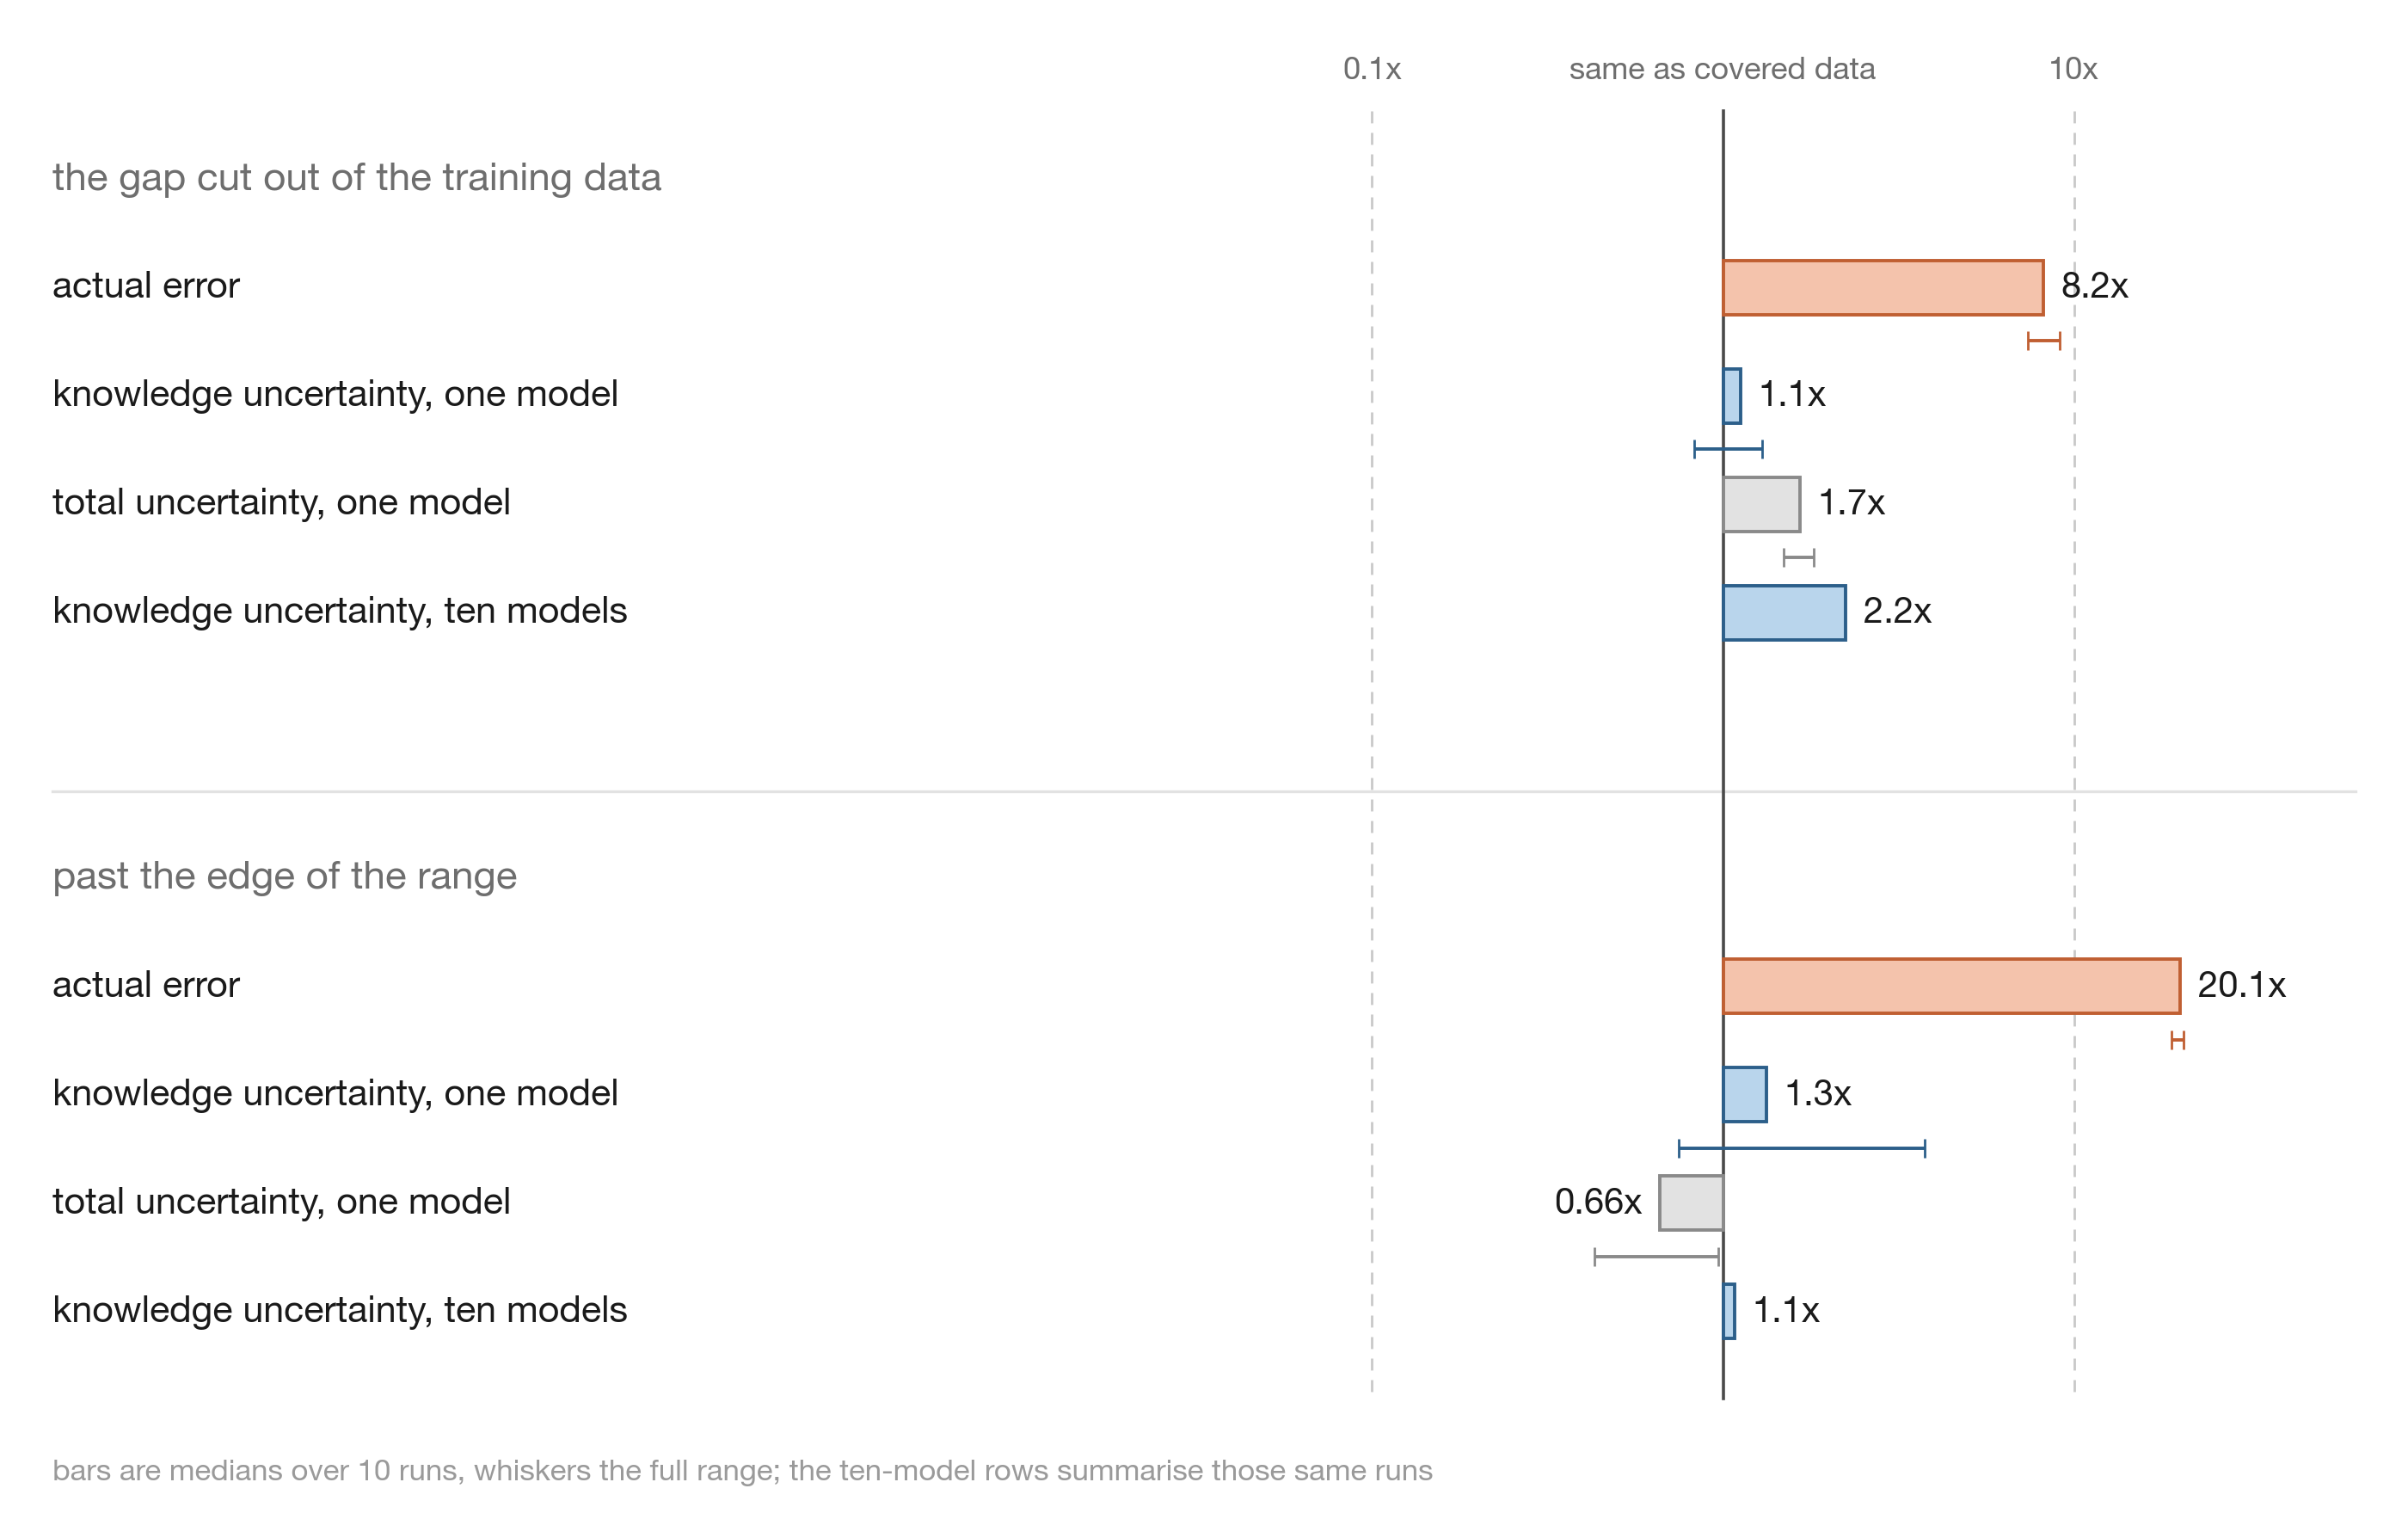

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_F, BLUE_E = "#B9D5EC", "#2C5F8A"
CORAL_F, CORAL_E = "#F4C3AC", "#C05F32"
GREY_F, GREY_E = "#E2E2E2", "#8a8a8a"
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

BH, XMAX = 0.5, np.log10(40)
LEFT = np.log10(0.055) - 3.6
fig_w, fig_h = 13.8, 8.6


def band(col):
    return summary.loc["median", col], (summary.loc["min", col], summary.loc["max", col])


bars, titles, cursor = [], [], 0.95
for i, k in enumerate(OUT):
    if i:
        cursor += 1.45
    titles.append((cursor, LABELS[k]))
    cursor += 1.0
    rows_for_panel = [
        ("actual error", *band(f"{k}: error"), CORAL_F, CORAL_E),
        ("knowledge uncertainty, one model", *band(f"{k}: knowledge"), BLUE_F, BLUE_E),
        ("total uncertainty, one model", *band(f"{k}: total"), GREY_F, GREY_E),
        ("knowledge uncertainty, ten models", ens.signal_x[k], None, BLUE_F, BLUE_E),
    ]
    for entry in rows_for_panel:
        bars.append((cursor,) + entry)
        cursor += 1.0
YMAX = cursor + 0.7

fig = plt.figure(figsize=(fig_w, fig_h), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(LEFT, XMAX + 0.3)
ax.set_ylim(YMAX, -0.55)
ax.axis("off")

ax.add_line(Line2D([0, 0], [0.32, YMAX - 0.9], color="#4a4a4a", lw=1.3, zorder=1))
ax.text(0, 0.08, "same as covered data", ha="center", va="bottom", fontsize=13, color=TEXT_MUTED)
for tick in (0.1, 10):
    x = np.log10(tick)
    ax.add_line(Line2D([x, x], [0.32, YMAX - 0.9], color="#c9c9c9", lw=1.0,
                       ls=(0, (5, 4)), zorder=1))
    ax.text(x, 0.08, f"{tick:g}x", ha="center", va="bottom", fontsize=13, color=TEXT_MUTED)

for cy, label in titles:
    ax.text(LEFT + 0.1, cy, label, ha="left", va="center", fontsize=16.5, color=TEXT_MUTED)
ax.add_line(Line2D([LEFT + 0.1, XMAX + 0.2], [titles[1][0] - 0.8] * 2,
                   color="#e2e2e2", lw=1.2, zorder=0))

for cy, name, val, rng, fc, ec in bars:
    x = np.log10(val)
    ax.add_patch(Rectangle((min(0, x), cy - BH / 2), abs(x), BH,
                           facecolor=fc, edgecolor=ec, lw=1.4, zorder=3))
    ax.text(LEFT + 0.1, cy, name, ha="left", va="center", fontsize=15.5, color=INK)
    ha, offset = ("left", 0.05) if x >= 0 else ("right", -0.05)
    ax.text(x + offset, cy, f"{val:.2f}x" if val < 1 else f"{val:.1f}x",
            ha=ha, va="center", fontsize=15, color=INK)
    if rng:
        lo, hi = np.log10(rng[0]), np.log10(rng[1])
        ax.errorbar(x, cy + BH / 2 + 0.24, xerr=[[x - lo], [hi - x]], fmt="none",
                    ecolor=ec, elinewidth=1.4, capsize=4, zorder=5)

ax.text(LEFT + 0.1, YMAX - 0.22,
        f"bars are medians over {len(runs)} runs, whiskers the full range; "
        f"the ten-model rows summarise those same runs",
        ha="left", va="center", fontsize=12.5, color=TEXT_FAINT)

fig.savefig("catboost_sglb_knowledge_uncertainty.png", facecolor="white")
plt.show()

## Takeaway

Knowledge uncertainty is cheap and it does separate regions on average. Three things limit what you
can do with it.

It carries no scale. In the gap the error is around ten times the covered level while the reported
uncertainty stays close to it, and squaring hides that, since both uncertainty columns are
variances.

It does not rank points inside a region, and past the edge of the training range it is a single
constant for every point. A nearest-neighbour distance to the training set ranks the error better
and costs one line.

The total, which is what `TotalUncertainty` hands you, is dominated by data uncertainty and points
the wrong way out of range, reporting more confidence where the model is worst.

Ten independently trained models see the gap much better. Neither version is dependable past the
edge of the range, and that result moves with the hyperparameters.